In [1]:
import pandas as pd
import keras
import numpy as np
from tensorflow.python.keras.utils.np_utils import to_categorical

from tokenizer import Tokenizer

csv = pd.read_csv("dataset/topic_dataset.csv")
data = csv.text
label = csv.label
tokenizer_data = Tokenizer()
tokenizer_label = Tokenizer()

In [2]:
split = int(len(data) * 0.8)

x_train = data[:split].tolist()
y_train = label[:split].tolist()
x_test = data[split:].tolist()
y_test = label[split:].tolist()

In [3]:
split = int(len(data) * 0.8)
x_train_raw, x_test_raw = data[:split].tolist(), data[split:].tolist()
y_train_raw, y_test_raw = label[:split].tolist(), label[split:].tolist()

# 1) tokenize text FIRST so the tokenizer's vocab (num_words) gets built
x_train_tok = [tokenizer_data(t) for t in x_train_raw]
x_test_tok  = [tokenizer_data(t) for t in x_test_raw]
print("num_words:", tokenizer_data.num_words)      # should now be a real int, not None

# 2) NOW build the multi-hot encoder
multi_hot = keras.layers.CategoryEncoding(
    num_tokens=tokenizer_data.num_words, output_mode="multi_hot")
x_train = multi_hot(x_train_tok)
x_test  = multi_hot(x_test_tok)

# labels: topic name -> class index -> one-hot
classes = sorted(label.unique())
label_to_idx = {c: i for i, c in enumerate(classes)}
num_classes = len(classes)
y_train = keras.utils.to_categorical([label_to_idx[l] for l in y_train_raw], num_classes)
y_test  = keras.utils.to_categorical([label_to_idx[l] for l in y_test_raw],  num_classes)
print("x_train:", x_train.shape, "| y_train:", y_train.shape)

num_words: 464
x_train: (2400, 464) | y_train: (2400, 6)


In [4]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")
model = keras.Sequential(
    [
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(6, activation="softmax")
    ]
)

In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy]
)

In [6]:
history = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.2)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1698 - loss: 1.7979 - top_3_accuracy: 0.5010 - val_accuracy: 0.1729 - val_loss: 1.7906 - val_top_3_accuracy: 0.5208
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1698 - loss: 1.7943 - top_3_accuracy: 0.5016 - val_accuracy: 0.1729 - val_loss: 1.7891 - val_top_3_accuracy: 0.5396
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1698 - loss: 1.7937 - top_3_accuracy: 0.4990 - val_accuracy: 0.1833 - val_loss: 1.7898 - val_top_3_accuracy: 0.5396
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1620 - loss: 1.7925 - top_3_accuracy: 0.5089 - val_accuracy: 0.1542 - val_loss: 1.7933 - val_top_3_accuracy: 0.5104
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1693 - loss: 1.7921 - top_3_accuracy: 0.5031 - val_accuracy: 0.1542 - val_loss: 1.7951 - val_top_3_accuracy: 0.4604
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1693 - loss: 1.7925 - top_3_accuracy: 0.5010 - 

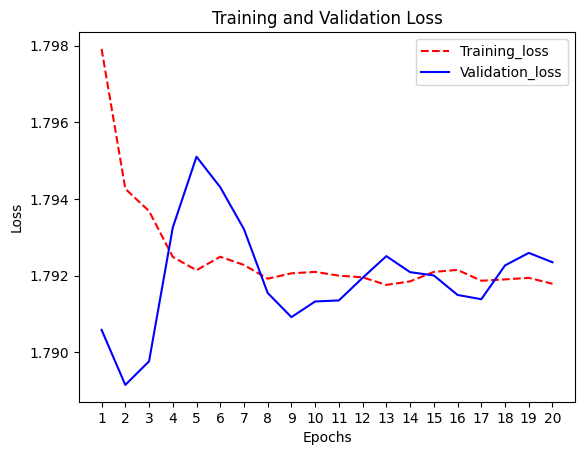

In [7]:
import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training_loss")
plt.plot(epochs, val_loss, "b", label="Validation_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.show()

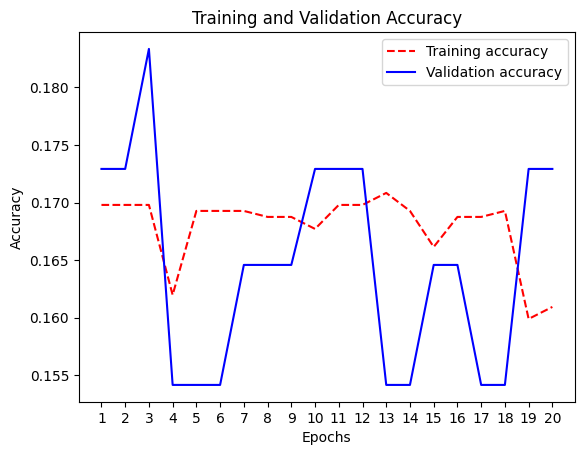

In [8]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()